### Medida Cosseno 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
def similaridade_cosseno(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

def angulo_graus(u, v):
    return np.degrees(np.arccos(np.clip(similaridade_cosseno(u, v), -1, 1)))

In [3]:
vetores = {
    "A": np.array([3.0, 7.0]),
    "B": np.array([2.0, 9.0]),
    "C": np.array([12.0, 1.0]),
}

In [4]:
pares = [("A", "B"), ("A", "C"), ("B", "C")]
resultados = {}

In [5]:
print("=" * 50)
print("  Similaridade de Cosseno — 1º Quadrante")
print("=" * 50)
for nome, v in vetores.items():
    print(f"  Vetor {nome}: {v}")
print()
for la, lb in pares:
    sim = similaridade_cosseno(vetores[la], vetores[lb])
    ang = angulo_graus(vetores[la], vetores[lb])
    resultados[(la, lb)] = {"sim": sim, "angulo": ang}
    print(f"  cos({la}, {lb}) = {sim:+.4f}   |   ângulo = {ang:.2f}°")
print("=" * 50)

  Similaridade de Cosseno — 1º Quadrante
  Vetor A: [3. 7.]
  Vetor B: [2. 9.]
  Vetor C: [12.  1.]

  cos(A, B) = +0.9827   |   ângulo = 10.67°
  cos(A, C) = +0.4689   |   ângulo = 62.04°
  cos(B, C) = +0.2972   |   ângulo = 72.71°



Gráfico salvo em: cosine_similarity_q1.png


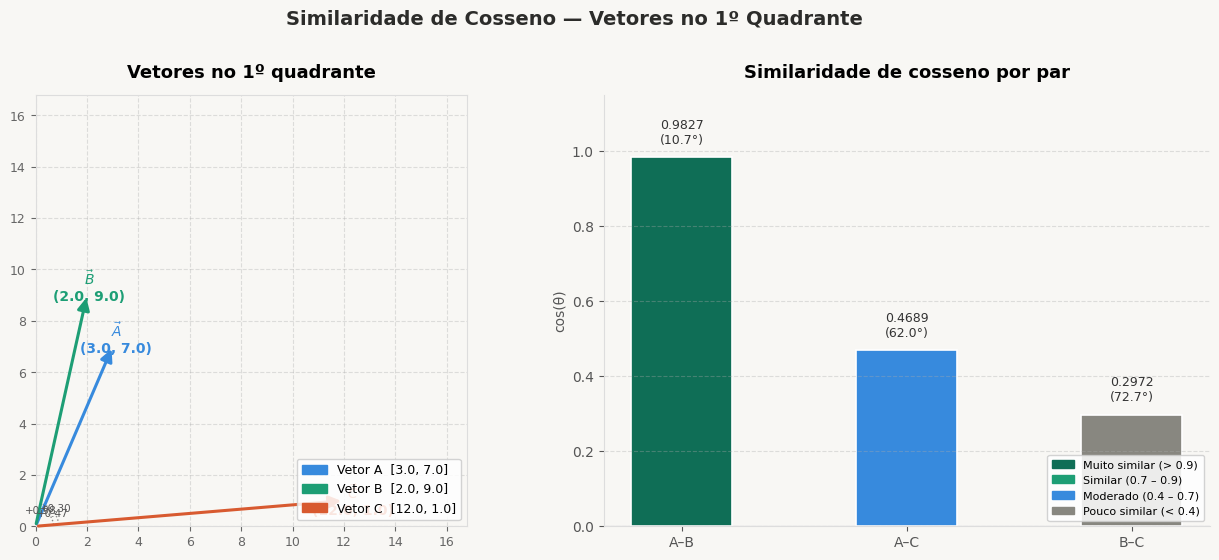

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor("#f8f7f4")
CORES = {"A": "#378ADD", "B": "#1D9E75", "C": "#D85A30"}

ax1 = axes[0]
ax1.set_facecolor("#f8f7f4")
ax1.set_title("Vetores no 1º quadrante", fontsize=13, fontweight="bold", pad=12)
lim = max(v.max() for v in vetores.values()) * 1.4
ax1.set_xlim(0, lim)
ax1.set_ylim(0, lim)
ax1.grid(True, linestyle="--", alpha=0.35, color="#aaaaaa")
ax1.set_aspect("equal")
ax1.tick_params(labelsize=9, colors="#666666")
for spine in ax1.spines.values():
    spine.set_edgecolor("#dddddd")

for nome, v in vetores.items():
    cor = CORES[nome]
    ax1.annotate("", xy=v, xytext=[0,0],
        arrowprops=dict(arrowstyle="-|>", color=cor, lw=2.2, mutation_scale=18))
    off = v / np.linalg.norm(v) * 0.35
    ax1.text(v[0]+off[0], v[1]+off[1],
        f"$\\vec{{{nome}}}$\n({v[0]:.1f}, {v[1]:.1f})",
        color=cor, fontsize=10, fontweight="bold", ha="center", va="center")

arc_radii = [0.5, 0.7, 0.9]
for (la, lb), raio in zip(pares, arc_radii):
    va, vb = vetores[la], vetores[lb]
    ang_a = np.degrees(np.arctan2(va[1], va[0]))
    ang_b = np.degrees(np.arctan2(vb[1], vb[0]))
    ang_min, ang_max = sorted([ang_a, ang_b])
    arc = mpatches.Arc([0,0], 2*raio, 2*raio, angle=0,
                       theta1=ang_min, theta2=ang_max,
                       color="#888888", lw=1.0, linestyle=":")
    ax1.add_patch(arc)
    mid = np.radians((ang_min+ang_max)/2)
    ax1.text((raio+0.15)*np.cos(mid), (raio+0.15)*np.sin(mid),
        f"{resultados[(la,lb)]['sim']:+.2f}",
        fontsize=7.5, ha="center", va="center", color="#555555")

patches = [mpatches.Patch(color=CORES[n], label=f"Vetor {n}  {vetores[n].tolist()}") for n in vetores]
ax1.legend(handles=patches, fontsize=9, loc="lower right", framealpha=0.85, edgecolor="#cccccc")

ax2 = axes[1]
ax2.set_facecolor("#f8f7f4")
ax2.set_title("Similaridade de cosseno por par", fontsize=13, fontweight="bold", pad=12)
nomes_pares = [f"{la}–{lb}" for la, lb in pares]
valores = [resultados[p]["sim"] for p in pares]
angulos = [resultados[p]["angulo"] for p in pares]
bar_cores = ["#0F6E56" if s > 0.9 else "#1D9E75" if s > 0.7 else "#378ADD" if s > 0.4 else "#888780" for s in valores]
bars = ax2.bar(nomes_pares, valores, color=bar_cores, width=0.45, edgecolor="white", linewidth=1.2)
ax2.set_ylim(0, 1.15)
ax2.axhline(0, color="#aaaaaa", linewidth=0.8)
ax2.grid(axis="y", linestyle="--", alpha=0.35, color="#aaaaaa")
ax2.set_ylabel("cos(θ)", fontsize=10, color="#555555")
ax2.tick_params(labelsize=10, colors="#555555")
for spine in ["top","right"]: ax2.spines[spine].set_visible(False)
for spine in ["left","bottom"]: ax2.spines[spine].set_edgecolor("#dddddd")
for bar, val, ang in zip(bars, valores, angulos):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.03,
        f"{val:.4f}\n({ang:.1f}°)",
        ha="center", va="bottom", fontsize=9, fontweight="500", color="#333333")

legenda = [
    mpatches.Patch(color="#0F6E56", label="Muito similar (> 0.9)"),
    mpatches.Patch(color="#1D9E75", label="Similar (0.7 – 0.9)"),
    mpatches.Patch(color="#378ADD", label="Moderado (0.4 – 0.7)"),
    mpatches.Patch(color="#888780", label="Pouco similar (< 0.4)"),
]
ax2.legend(handles=legenda, fontsize=8, loc="lower right", framealpha=0.85, edgecolor="#cccccc")

plt.suptitle("Similaridade de Cosseno — Vetores no 1º Quadrante",
             fontsize=14, fontweight="bold", y=1.01, color="#2c2c2a")
plt.tight_layout()
plt.savefig("cosine_similarity_q1.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("\nGráfico salvo em: cosine_similarity_q1.png")
plt.show()